In [1]:
import sys

sys.path.append("..")

import warnings

import pandas as pd
import torch

import os

from distilrl.utils.misc import seed_everything
from distilrl.constants import CONFIG_DIR, DATASET_DIR, MODEL_DIR
from pathlib import Path

from datasets import Dataset

from hydra.utils import instantiate, get_class

warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2
%cd ..

device = "cuda" if torch.cuda.is_available() else "cpu"
device

/home/ivanov.dko/projects/distilrl


'cpu'

In [2]:
odd_set = Dataset.load_from_disk(Path(DATASET_DIR, "odd_set"), )
even_set = Dataset.load_from_disk(Path(DATASET_DIR, "even_set"))
uniform_set = Dataset.load_from_disk(Path(DATASET_DIR, "uniform_set"))

for dataset in [odd_set, even_set, uniform_set]:
    dataset.set_format(type="torch")

In [3]:
even_set = even_set.select(range(3000))
uniform_set = uniform_set.select(range(3000))

In [4]:
from torch.utils.data import DataLoader

odd_loader = DataLoader(odd_set, batch_size=128, shuffle=True)
even_loader = DataLoader(even_set, batch_size=128, shuffle=False)
uniform_loader = DataLoader(uniform_set, batch_size=128, shuffle=False)

In [43]:
from distilrl.models import DecisionTransformer

dt = DecisionTransformer(
    num_states = 0,
    num_actions = 10,
    seq_len = 64,
    episode_len = 20000,
    embedding_dim = 128,
    num_layers = 4,
    num_heads = 4,
    attention_dropout = 0.1,
    residual_dropout = 0.1,
    embedding_dropout = 0.1,
    feedforward_dim=512,
    max_action = 1.0,
    emb_strategy = "stack",
    optimizer = torch.optim.Adam,
    optimizer_kwargs = dict(lr=1e-4, betas=(0.9, 0.99)),
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts,
    scheduler_kwargs=dict(T_0=10000, eta_min=2e-6)
)

In [21]:
batch = next(iter(odd_loader))

In [22]:
out = dt.forward(
    actions=batch["actions"],
    time_steps=batch["time_steps"],
    rewards=batch["rewards"],
    # states = states
)

In [43]:
from torch.nn import functional as F

F.cross_entropy(out, batch["future_actions"].squeeze(1), reduction="mean")

tensor(2.2901, grad_fn=<NllLossBackward0>)

In [31]:
batch["future_actions"].squeeze(1)

tensor([7, 3, 1, 3, 3, 9, 3, 1, 1, 7, 5, 3, 1, 3, 5, 5, 0, 1, 3, 1, 9, 3, 7, 3,
        3, 3, 3, 3, 1, 5, 1, 3, 9, 3, 1, 3, 3, 1, 3, 7, 1, 1, 3, 3, 3, 3, 1, 3,
        3, 3, 1, 3, 7, 3, 3, 1, 3, 3, 3, 3, 1, 3, 1, 1, 5, 9, 3, 3, 1, 3, 3, 1,
        3, 3, 1, 3, 3, 1, 3, 1, 3, 7, 3, 3, 3, 3, 8, 1, 1, 1, 1, 3, 3, 1, 3, 7,
        3, 7, 3, 3, 3, 3, 1, 3, 3, 3, 1, 3, 3, 3, 5, 3, 1, 3, 1, 1, 1, 3, 1, 3,
        3, 3, 3, 3, 3, 1, 1, 3])

In [32]:
loss(out, batch["future_actions"].squeeze(1))

tensor(2.5526, grad_fn=<NllLossBackward0>)

In [44]:
import pytorch_lightning as pl

trainer = pl.Trainer(
    enable_model_summary=True,
    accelerator="cpu",
    max_steps=10000,
    logger=None,
    gradient_clip_val=1.0, gradient_clip_algorithm="norm"
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [45]:
trainer.fit(dt, odd_loader, [even_loader, uniform_loader])


   | Name         | Type             | Params | Mode 
-----------------------------------------------------------
0  | loss         | CrossEntropyLoss | 0      | train
1  | emb_drop     | Dropout          | 0      | train
2  | emb_norm     | LayerNorm        | 256    | train
3  | out_norm     | LayerNorm        | 256    | train
4  | timestep_emb | Embedding        | 2.6 M  | train
5  | state_emb    | Embedding        | 0      | train
6  | action_emb   | Embedding        | 1.3 K  | train
7  | return_emb   | Linear           | 256    | train
8  | blocks       | ModuleList       | 793 K  | train
9  | action_head  | Linear           | 1.3 K  | train
10 | conv_out     | Conv1d           | 8.3 K  | train
-----------------------------------------------------------
3.4 M     Trainable params
0         Non-trainable params
3.4 M     Total params
13.491    Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

{'loss': tensor(2.3452), 'accuracy': tensor(0.0547)} tensor(0.0547)
{'loss': tensor(2.2946), 'accuracy': tensor(0.1016)} tensor(0.1016)
{'loss': tensor(2.2492), 'accuracy': tensor(0.1406)} tensor(0.1406)
{'loss': tensor(2.2600), 'accuracy': tensor(0.1641)} tensor(0.1641)


Training: |          | 0/? [00:00<?, ?it/s]

{'loss': tensor(2.4813, grad_fn=<MeanBackward0>), 'accuracy': tensor(0.0391)} tensor(0.0391)
{'loss': tensor(2.4409, grad_fn=<MeanBackward0>), 'accuracy': tensor(0.0625)} tensor(0.0625)
{'loss': tensor(2.4271, grad_fn=<MeanBackward0>), 'accuracy': tensor(0.0625)} tensor(0.0625)
{'loss': tensor(2.4006, grad_fn=<MeanBackward0>), 'accuracy': tensor(0.0703)} tensor(0.0703)
{'loss': tensor(2.3642, grad_fn=<MeanBackward0>), 'accuracy': tensor(0.0703)} tensor(0.0703)
{'loss': tensor(2.3050, grad_fn=<MeanBackward0>), 'accuracy': tensor(0.0938)} tensor(0.0938)
{'loss': tensor(2.3165, grad_fn=<MeanBackward0>), 'accuracy': tensor(0.0938)} tensor(0.0938)
{'loss': tensor(2.2179, grad_fn=<MeanBackward0>), 'accuracy': tensor(0.2109)} tensor(0.2109)
{'loss': tensor(2.2198, grad_fn=<MeanBackward0>), 'accuracy': tensor(0.1797)} tensor(0.1797)
{'loss': tensor(2.1584, grad_fn=<MeanBackward0>), 'accuracy': tensor(0.2969)} tensor(0.2969)
{'loss': tensor(2.1709, grad_fn=<MeanBackward0>), 'accuracy': tensor(0

Validation: |          | 0/? [00:00<?, ?it/s]

{'loss': tensor(2.3713), 'accuracy': tensor(0.0391)} tensor(0.0391)
{'loss': tensor(2.2444), 'accuracy': tensor(0.0234)} tensor(0.0234)
{'loss': tensor(2.2976), 'accuracy': tensor(0.0234)} tensor(0.0234)
{'loss': tensor(2.2999), 'accuracy': tensor(0.0547)} tensor(0.0547)
{'loss': tensor(2.3021), 'accuracy': tensor(0.0312)} tensor(0.0312)
{'loss': tensor(2.2988), 'accuracy': tensor(0.0312)} tensor(0.0312)
{'loss': tensor(2.3359), 'accuracy': tensor(0.0469)} tensor(0.0469)
{'loss': tensor(2.3053), 'accuracy': tensor(0.0234)} tensor(0.0234)
{'loss': tensor(2.3298), 'accuracy': tensor(0.0312)} tensor(0.0312)
{'loss': tensor(2.3016), 'accuracy': tensor(0.0547)} tensor(0.0547)
{'loss': tensor(2.3205), 'accuracy': tensor(0.0312)} tensor(0.0312)
{'loss': tensor(2.2966), 'accuracy': tensor(0.0469)} tensor(0.0469)
{'loss': tensor(2.3138), 'accuracy': tensor(0.0547)} tensor(0.0547)
{'loss': tensor(2.3083), 'accuracy': tensor(0.0312)} tensor(0.0312)
{'loss': tensor(2.3637), 'accuracy': tensor(0.04

Validation: |          | 0/? [00:00<?, ?it/s]

{'loss': tensor(2.0238), 'accuracy': tensor(0.0938)} tensor(0.0938)
{'loss': tensor(1.9212), 'accuracy': tensor(0.1094)} tensor(0.1094)
{'loss': tensor(1.9559), 'accuracy': tensor(0.1406)} tensor(0.1406)
{'loss': tensor(1.9891), 'accuracy': tensor(0.1797)} tensor(0.1797)
{'loss': tensor(1.8986), 'accuracy': tensor(0.1797)} tensor(0.1797)
{'loss': tensor(1.9369), 'accuracy': tensor(0.1406)} tensor(0.1406)
{'loss': tensor(2.0292), 'accuracy': tensor(0.1172)} tensor(0.1172)
{'loss': tensor(1.9867), 'accuracy': tensor(0.1328)} tensor(0.1328)
{'loss': tensor(1.9933), 'accuracy': tensor(0.1172)} tensor(0.1172)
{'loss': tensor(1.9790), 'accuracy': tensor(0.1016)} tensor(0.1016)
{'loss': tensor(2.0030), 'accuracy': tensor(0.1250)} tensor(0.1250)
{'loss': tensor(1.9563), 'accuracy': tensor(0.1406)} tensor(0.1406)
{'loss': tensor(1.9453), 'accuracy': tensor(0.1719)} tensor(0.1719)
{'loss': tensor(2.0186), 'accuracy': tensor(0.0938)} tensor(0.0938)
{'loss': tensor(2.0520), 'accuracy': tensor(0.10

In [122]:
states = torch.rand(32, 10).long()
actions = torch.rand(32, 10).long()
time_steps = torch.rand(32, 10).long()
rewards_to_go = torch.rand(32, 10).float()

out = dt.forward(
    actions=actions,
    time_steps=time_steps,
    rewards=rewards_to_go,
    states = states
)

In [134]:
actions.shape

torch.Size([32, 10])

In [140]:
nn.CrossEntropyLoss(reduction="none")(out.transpose(1, 2), actions)

tensor([[2.9570, 3.0845, 3.1484, 3.3762, 2.7431, 3.2135, 2.9878, 2.9765, 3.4453,
         3.1878],
        [2.9429, 3.0783, 3.1483, 3.3827, 2.7360, 3.2184, 3.0101, 2.9789, 3.4352,
         3.1806],
        [2.9534, 3.0703, 3.1391, 3.3721, 2.7315, 3.2258, 2.9938, 2.9925, 3.4451,
         3.1915],
        [2.9574, 3.0708, 3.1661, 3.3848, 2.7149, 3.2197, 2.9970, 2.9671, 3.4357,
         3.1716],
        [2.9587, 3.0732, 3.1519, 3.3681, 2.7209, 3.2308, 2.9922, 2.9624, 3.4386,
         3.1746],
        [2.9586, 3.0811, 3.1453, 3.3703, 2.7359, 3.2255, 2.9959, 2.9841, 3.4486,
         3.2014],
        [2.9557, 3.0808, 3.1572, 3.3829, 2.7237, 3.2262, 3.0038, 2.9827, 3.4394,
         3.1786],
        [2.9488, 3.0674, 3.1384, 3.3768, 2.7217, 3.2308, 2.9996, 2.9847, 3.4363,
         3.1848],
        [2.9561, 3.0758, 3.1643, 3.3856, 2.7240, 3.2220, 2.9999, 2.9869, 3.4543,
         3.1808],
        [2.9513, 3.0666, 3.1494, 3.3740, 2.7174, 3.2296, 2.9989, 2.9651, 3.4379,
         3.1753],
        [2

Надо со всего предсказывать? Почему изначально только стейты?

In [111]:
out.shape

torch.Size([2, 3, 20])

In [107]:
from distilrl.models import CausalBase
from distilrl.dt import TransformerBlock
from typing import Optional

class DecisionTransformer(CausalBase):
    def __init__(
        self,
        num_actions: int,
        num_states: int | None = None,
        seq_len: int = 10,
        episode_len: int = 1000,
        embedding_dim: int = 128,
        num_layers: int = 4,
        num_heads: int = 8,
        attention_dropout: float = 0.0,
        residual_dropout: float = 0.0,
        embedding_dropout: float = 0.0,
        max_action: float = 1.0,
        emb_strategy: str = "stack"
    ):
        super().__init__()
        self.emb_drop = nn.Dropout(embedding_dropout)
        self.emb_norm = nn.LayerNorm(embedding_dim)
        self.out_norm = nn.LayerNorm(embedding_dim)
        self.emb_strategy = emb_strategy
        
        self.timestep_emb = nn.Embedding(episode_len + seq_len, embedding_dim)
        if num_states is not None:
            self.state_emb = nn.Embedding(num_states, embedding_dim)
        self.action_emb = nn.Embedding(num_actions, embedding_dim)
        self.return_emb = nn.Linear(1, embedding_dim)

        self.seq_len = seq_len
        self.num_stacks = 1 + int(self.emb_strategy == "stack") + int(num_states is not None and num_states != 0)
        self.seq_len *= self.num_stacks
        self.blocks = nn.ModuleList(
            [
                TransformerBlock(
                    seq_len=self.seq_len,
                    embedding_dim=embedding_dim,
                    num_heads=num_heads,
                    attention_dropout=attention_dropout,
                    residual_dropout=residual_dropout,
                )
                for _ in range(num_layers)
            ]
        )
        self.action_head = nn.Linear(embedding_dim, num_actions)
        self.embedding_dim = embedding_dim
        self.num_states = num_states
        self.num_actions = num_actions
        self.episode_len = episode_len
        self.max_action = max_action
        
        self.conv_out = nn.Conv1d(self.seq_len, self.seq_len // self.num_stacks, 1)

    #     self.apply(self._init_weights)

    # @staticmethod
    # def _init_weights(module: nn.Module):
    #     if isinstance(module, (nn.Linear, nn.Embedding)):
    #         torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
    #         if isinstance(module, nn.Linear) and module.bias is not None:
    #             torch.nn.init.zeros_(module.bias)
    #     elif isinstance(module, nn.LayerNorm):
    #         torch.nn.init.zeros_(module.bias)
    #         torch.nn.init.ones_(module.weight)

    def forward(
        self,
        actions: torch.Tensor,  # [batch_size, seq_len, action_dim]
        rewards: torch.Tensor,  # [batch_size, seq_len]
        time_steps: torch.Tensor,  # [batch_size, seq_len]
        states: Optional[torch.Tensor] = None,  # [batch_size, seq_len, state_dim]
        padding_mask: Optional[torch.Tensor] = None,  # [batch_size, seq_len]
    ) -> torch.FloatTensor:
        batch_size = actions.shape[0]
        # [batch_size, seq_len, emb_dim]
        time_emb = self.timestep_emb(time_steps)
        act_emb = self.action_emb(actions) + time_emb
        rewards_emb = self.return_emb(rewards.unsqueeze(-1)) + time_emb
        state_emb = None
        if self.num_stacks == 3:
            state_emb = self.state_emb(states) + time_emb

        # [batch_size, seq_len * 3, emb_dim], (r_0, s_0, a_0, r_1, s_1, a_1, ...)
        emb_list = [x for x in [rewards_emb, state_emb, act_emb] if x is not None]
        sequence = torch.stack(emb_list, dim=1)
        if self.emb_strategy == "stack":
            sequence = (
                sequence
                .permute(0, 2, 1, 3)
                .reshape(batch_size, self.seq_len, self.embedding_dim)
            )
        else:
            sequence = sequence.sum(1).reshape(batch_size, self.seq_len, self.embedding_dim)
            
        padding_list = [padding_mask] * self.num_stacks
        if padding_mask is not None:
            # [batch_size, seq_len * 3], stack mask identically to fit the sequence
            padding_mask = (
                torch.stack(padding_list, dim=1)
                .permute(0, 2, 1)
                .reshape(batch_size, self.seq_len)
            )
        # LayerNorm and Dropout (!!!) as in original implementation,
        # while minGPT & huggingface uses only embedding dropout
        out = self.emb_norm(sequence)
        out = self.emb_drop(out)

        for block in self.blocks:
            out = block(out, padding_mask=padding_mask)

        out = self.action_head(self.conv_out(self.out_norm(out)))
        return out

In [25]:
from omegaconf import OmegaConf

env_cfg, arm_cfg, policies_cfg = [
    OmegaConf.to_container(
    OmegaConf.load(Path(CONFIG_DIR, f"bandit/{cfg}.yaml"))
) for cfg in ["env", "arm", "policies"]]

In [18]:
n_arms = 10
n_runs = 1

In [71]:
probas = torch.rand(n_runs, n_arms)

In [85]:
torch.randint(low=1, high=5, size=(n_runs, n_arms//2))

tensor([[2, 3, 2, 4, 4],
        [1, 4, 1, 4, 4],
        [1, 2, 2, 1, 3],
        [1, 1, 2, 3, 2],
        [1, 2, 1, 4, 2],
        [4, 4, 4, 4, 2],
        [3, 2, 1, 2, 2],
        [1, 1, 1, 2, 4],
        [2, 2, 2, 2, 1],
        [2, 4, 3, 3, 1],
        [2, 2, 2, 1, 4],
        [1, 2, 3, 2, 2],
        [2, 4, 1, 3, 4],
        [2, 2, 2, 2, 1],
        [3, 1, 2, 4, 1],
        [2, 1, 1, 2, 4],
        [1, 2, 4, 4, 1],
        [2, 2, 1, 3, 3],
        [3, 3, 4, 3, 3],
        [2, 3, 2, 3, 2],
        [4, 4, 4, 2, 2],
        [1, 3, 3, 1, 4],
        [3, 3, 1, 1, 3],
        [3, 4, 4, 2, 3],
        [4, 4, 2, 3, 2],
        [1, 4, 2, 2, 1],
        [2, 1, 3, 1, 1],
        [3, 4, 1, 1, 1],
        [3, 1, 4, 1, 3],
        [4, 2, 2, 2, 3],
        [2, 4, 1, 2, 3],
        [4, 3, 3, 3, 4],
        [2, 3, 4, 2, 3],
        [4, 1, 4, 4, 1],
        [3, 1, 3, 2, 2],
        [2, 1, 2, 4, 2],
        [2, 3, 2, 1, 1],
        [4, 1, 2, 4, 2],
        [3, 4, 1, 4, 4],
        [4, 3, 2, 1, 1],


In [19]:
assert n_arms % 2 == 0
strategy = "odd"

if strategy in ["odd", "even"]:
    train_probas = torch.zeros(n_runs, n_arms)
    train_probas[:, ::2] = 1
    train_probas[:, ::2] += torch.FloatTensor(n_runs, n_arms // 2).uniform_(-0.5, 0)
    train_probas[:, 1::2] += torch.FloatTensor(n_runs, n_arms // 2).uniform_(0, 0.5)
    if strategy == "odd":
        train_probas = 1 - train_probas
else:
    train_probas = torch.FloatTensor(n_runs, n_arms).uniform_(0, 1)
train_probas = train_probas.tolist()

In [26]:
policies = list(policies_cfg.values())

In [140]:
1 - torch.tensor(train_probas)

tensor([[0.0398, 0.6054, 0.2507, 0.6024, 0.3601, 0.7029, 0.4644, 0.6037, 0.4331,
         0.8745]])

In [27]:
for policy in policies:
    policy["archtype"] = get_class(policy["archtype"])

In [30]:
env_cfg["environment"] = envs

In [20]:
envs = [{"arm_type": arm, "params": params} for arm, params in zip([Bernoulli for _ in range(100)], train_probas)]

In [28]:
env_cfg["policies"] = policies

In [31]:
from SMPyBandits.Environment import Evaluator

env_cfg["verbosity"] = 0
evaluator = Evaluator(env_cfg)

Number of policies in this comparison: 6
Time horizon: 20000
Number of repetitions: 1
Sampling rate for plotting, delta_t_plot: 50
Number of jobs for parallelization: -1
Using this dictionary to create a new environment:
 {'arm_type': <class 'SMPyBandits.Arms.Bernoulli.Bernoulli'>, 'params': [0.9602268934249878, 0.3945833146572113, 0.7493494749069214, 0.39760923385620117, 0.6398613452911377, 0.29712265729904175, 0.5355809330940247, 0.3963499367237091, 0.5669471025466919, 0.12549543380737305]}


Creating a new MAB problem ...
  Reading arms of this MAB problem from a dictionnary 'configuration' = {'arm_type': <class 'SMPyBandits.Arms.Bernoulli.Bernoulli'>, 'params': [0.9602268934249878, 0.3945833146572113, 0.7493494749069214, 0.39760923385620117, 0.6398613452911377, 0.29712265729904175, 0.5355809330940247, 0.3963499367237091, 0.5669471025466919, 0.12549543380737305]} ...
 - with 'arm_type' = <class 'SMPyBandits.Arms.Bernoulli.Bernoulli'>
 - with 'params' = [0.9602268934249878, 0.3945833

In [32]:
from tqdm.auto import tqdm

for idx, env in tqdm(enumerate(evaluator.envs)):
    evaluator.startOneEnv(idx, env)

0it [00:00, ?it/s]



Evaluating environment: MAB(nbArms: 10, arms: [B(0.96), B(0.395), B(0.749), B(0.398), B(0.64), B(0.297), B(0.536), B(0.396), B(0.567), B(0.125)], minArm: 0.125, maxArm: 0.96)
- Adding policy #1 = {'archtype': <class 'SMPyBandits.Policies.DiscountedThompson.DiscountedThompson'>, 'params': {'gamma': 0.95, 'alpha': 1}} ...
  Creating this policy from a dictionnary 'self.cfg['policies'][0]' = {'archtype': <class 'SMPyBandits.Policies.DiscountedThompson.DiscountedThompson'>, 'params': {'gamma': 0.95, 'alpha': 1}} ...
- Adding policy #2 = {'archtype': <class 'SMPyBandits.Policies.DiscountedUCB.DiscountedklUCB'>, 'params': {'gamma': 0.95}} ...
  Creating this policy from a dictionnary 'self.cfg['policies'][1]' = {'archtype': <class 'SMPyBandits.Policies.DiscountedUCB.DiscountedklUCB'>, 'params': {'gamma': 0.95}} ...
- Adding policy #3 = {'archtype': <class 'SMPyBandits.Policies.klUCB.klUCB'>, 'params': {}} ...
  Creating this policy from a dictionnary 'self.cfg['policies'][2]' = {'archtype'

Repeat||:   0%|          | 0/1 [00:00<?, ?it/s]

If you want the speed up brought by numba.jit, try to manually install numba and check that it works (installing llvmlite can be tricky, cf. https://github.com/numba/numba#custom-python-environments
If you want the speed up brought by numba.jit, try to manually install numba and check that it works (installing llvmlite can be tricky, cf. https://github.com/numba/numba#custom-python-environments


Time t:  79%|███████▉  | 15792/20000 [00:00<00:00, 17426.64it/s]

...

Time t: 100%|██████████| 20000/20000 [00:00<00:00, 29739.55it/s]


Repeat||:   0%|          | 0/1 [00:00<?, ?it/s]

If you want the speed up brought by numba.jit, try to manually install numba and check that it works (installing llvmlite can be tricky, cf. https://github.com/numba/numba#custom-python-environments
If you want the speed up brought by numba.jit, try to manually install numba and check that it works (installing llvmlite can be tricky, cf. https://github.com/numba/numba#custom-python-environments


Time t: 100%|██████████| 20000/20000 [00:03<00:00, 6006.09it/s]



Estimated order by the policy Exp3($\gamma: 0.01$) after 20000 steps: [9 5 1 3 7 8 6 4 2 0] ...
  ==> Optimal arm identification: 100.00% (relative success)...
  ==> Mean distance from optimal ordering: 27.00% (relative success)...


In [153]:
torch.stack([torch.tensor([2, 3]), torch.tensor([0, 4])], dim=1).sum(1, keepdim=True)

tensor([[2],
        [7]])


Giving the final ranks ...

Final ranking for this environment #0 : (using less accurate estimate of the regret)
- Policy 'D-klUCB($\gamma=0.95$)'	was ranked	1 / 6 for this simulation
	(last regret = 4.5391,	total regret = 4.5391,	total reward = 19226,	total weighted selection = 19200).
- Policy 'EmpiricalMeans'	was ranked	2 / 6 for this simulation
	(last regret = 5.1718,	total regret = 5.1718,	total reward = 19186,	total weighted selection = 19199).
- Policy 'kl-UCB'	was ranked	3 / 6 for this simulation
	(last regret = 42.085,	total regret = 42.085,	total reward = 19138,	total weighted selection = 19162).
- Policy 'UCB($\alpha=0.5$)'	was ranked	4 / 6 for this simulation
	(last regret = 44.922,	total regret = 44.922,	total reward = 19152,	total weighted selection = 19160).
- Policy 'Exp3($\gamma: 0.01$)'	was ranked	5 / 6 for this simulation
	(last regret = 2255,	total regret = 2255.2,	total reward = 16974,	total weighted selection = 16949).
- Policy 'DiscountedThompson($\gamma=0.95$)'

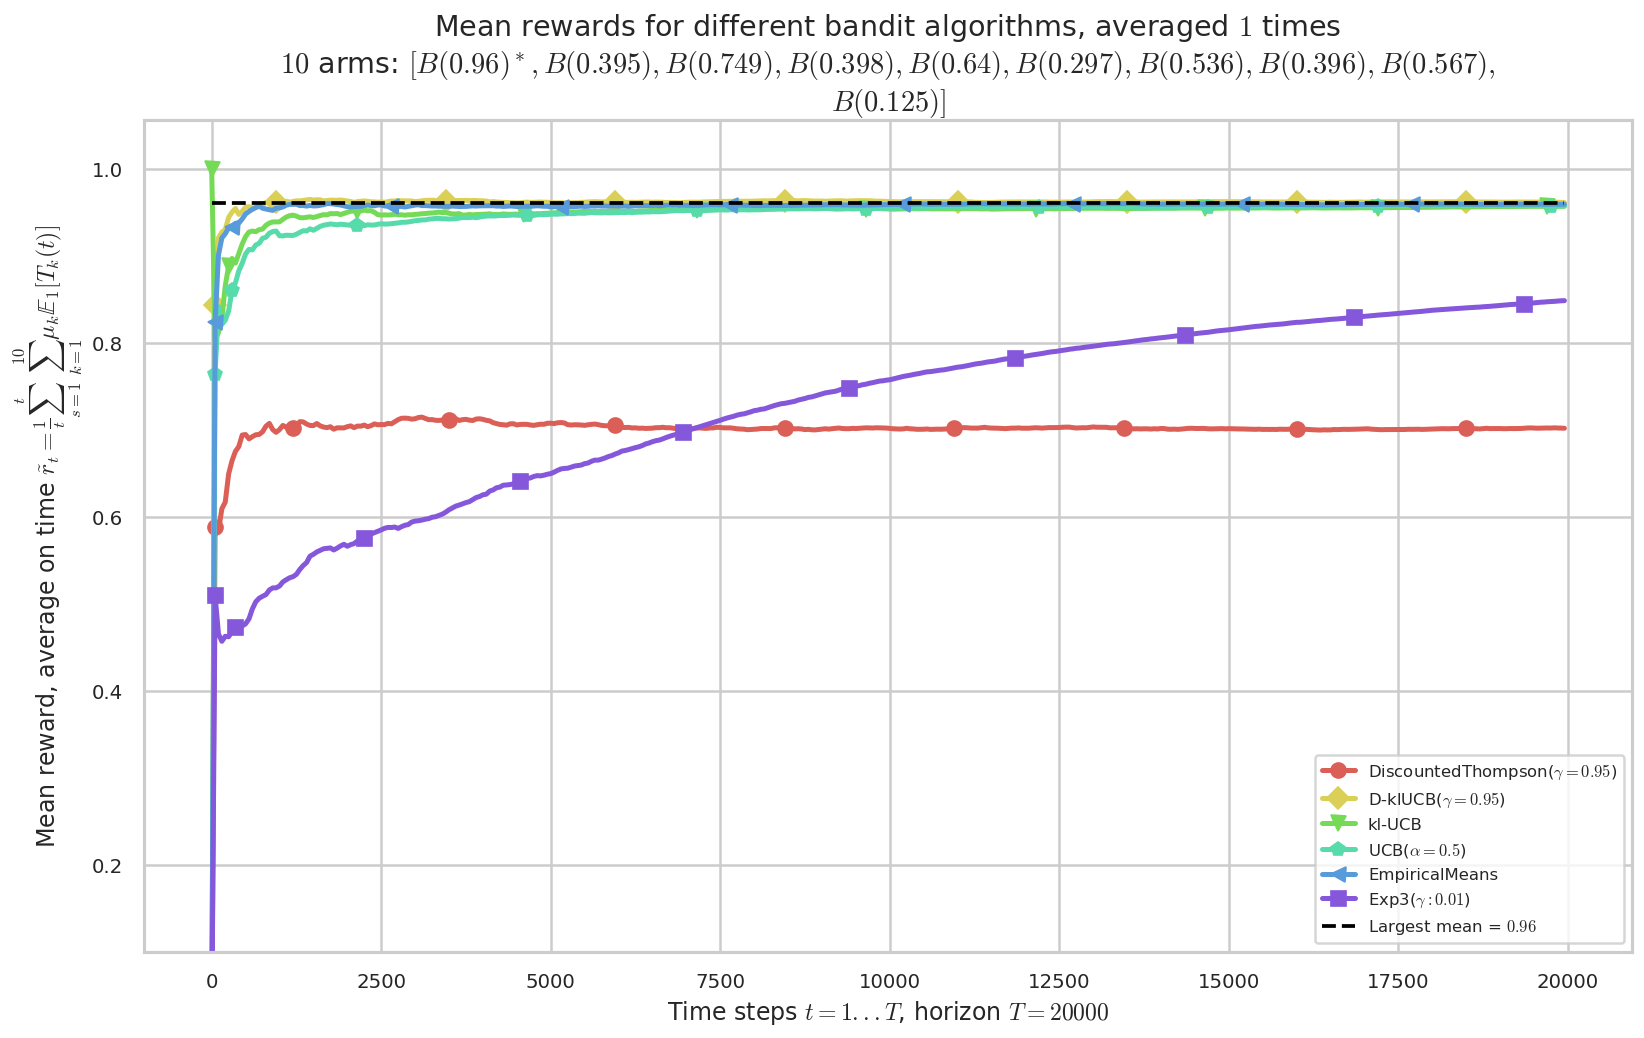

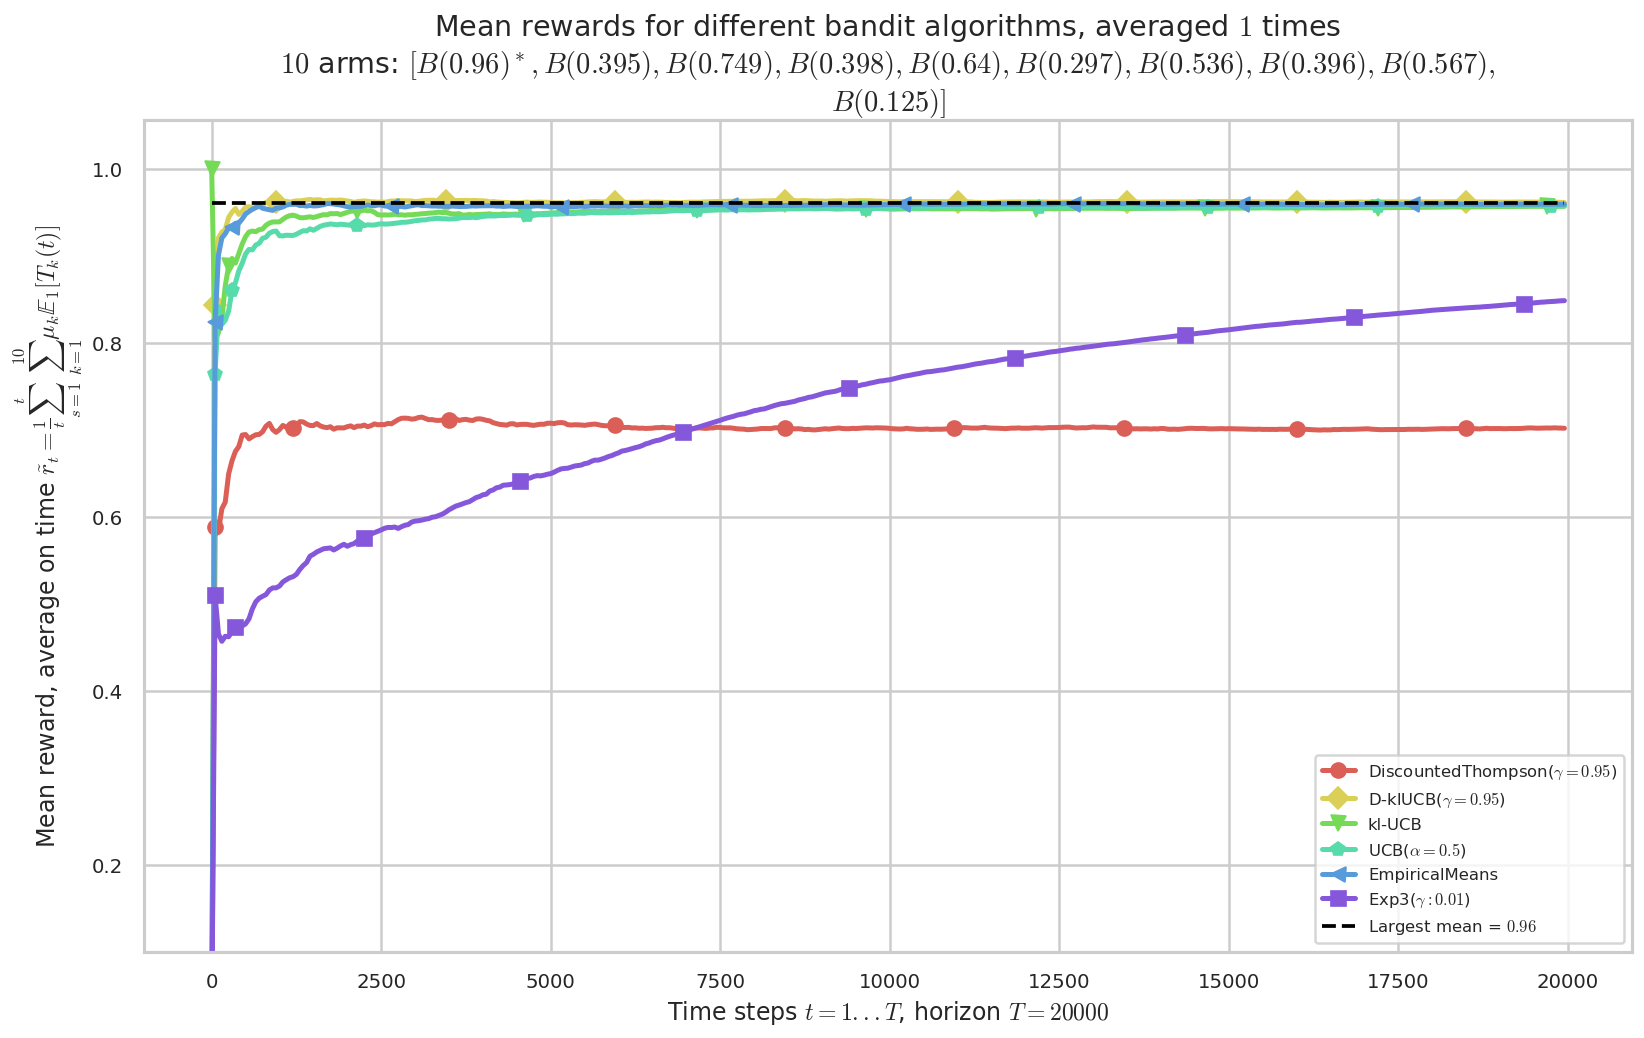

In [43]:
evaluator.printFinalRanking(0)
evaluator.plotRegrets(0, meanReward=True)

In [52]:
for i in range(6):
    print(evaluator.getRewards(i))

[0. 1. 0. ... 1. 1. 0.]
[0. 0. 0. ... 1. 0. 1.]
[1. 1. 1. ... 1. 1. 1.]
[0. 1. 0. ... 1. 1. 1.]
[0. 0. 0. ... 1. 1. 1.]
[0. 1. 1. ... 1. 1. 1.]


In [55]:
for i in range(6):
    print(evaluator.getAverageRewards(i))

[0.         0.5        0.33333333 ... 0.70167017 0.70168508 0.70165   ]
[0.         0.         0.         ... 0.96134613 0.96129806 0.9613    ]
[1.         1.         1.         ... 0.95689569 0.95689784 0.9569    ]
[0.         0.5        0.33333333 ... 0.95759576 0.95759788 0.9576    ]
[0.         0.         0.         ... 0.95929593 0.95929796 0.9593    ]
[0.         0.5        0.66666667 ... 0.84868487 0.84869243 0.8487    ]


In [143]:
from collections import Counter

print(evaluator.allPulls[0].argmax(1))

[[5 8 9 ... 8 4 6]
 [9 1 5 ... 0 0 0]
 [9 4 2 ... 0 0 0]
 [3 7 8 ... 0 0 0]
 [8 5 9 ... 0 0 0]
 [6 7 1 ... 0 0 0]]


In [90]:
for i in range(6):
    print(evaluator.lastPulls[0].shape)

(6, 10, 1)
(6, 10, 1)
(6, 10, 1)
(6, 10, 1)
(6, 10, 1)
(6, 10, 1)


In [27]:
dict(conf["params"])

ValueError: dictionary update sequence element #0 has length 8; 2 is required